# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Cicilia Beladina Luciano Gadja
- **Email:** CDCC185D6X1606@student.devacademy.id
- **ID Dicoding:** CDCC185D6X1606

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Berdasarkan kombinasi dari kondisi cuaca, suhu, dan jenis hari mana yang paling sering berkontribusi pada permintaan yang ekstrem pada bisnis *Bike Sharing*?
- Pertanyaan 2: Pada hari kerja, akhir pekan, dan libur nasional, bagaimana perbedaan perilaku masing-masing pengguna (terdaftar dan kasual) dalam menyewa sepeda?

## Import Semua Packages/Library yang Digunakan

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Sebagai langkah awal dalam analisis data, dataset yang berisi file bernama "day.csv" akan dimuat kedalam environment notebook. File ini berisi data penyewaan sepeda yang telah dirangkum dalam skala harian.

In [3]:
# Memuat file "day" menjadi DataFrame
day_df = pd.read_csv('day.csv')

# Menampilkan 5 baris pertama dari DataFrame "day_df"
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Berdasarkan hasil gathering tersebut, terlihat pada baris pertama kolom "casual" terdapat penurunan yang drastis, yang semula permintaan pada tanggal 1sebanyak 331 turun ke 131 di tanggal 2. Penurunan ini terjadi meskipun kedua tanggal tersebut sama-sama tergolong akhir pekan (weekday 6 atau hari sabtu dan weekday 0 atau hari minggu). Mengindikasikan bahwa tipe hari berpengaruh terhadap komposisi permintaan pengguna.
- Ditemukkan bahwa hampir setiap nilai sudah dilakukan label encoding, ditambah penamaan kolom yang disingkat (yr, mnth, hum), sehingga bisa menimbulkan ambiguitas.

### Assessing Data

Setelah melalui tahap gathering, selanjutnya keseluruhan data pada file "day" akan dinilai kualitasnya, untuk melihat apakah terdapat permasalahan yang bisa mengganggu analisis akhir, berikut ini tahap-tahap yang akan dilakukan:

1. Tipe Data: data akan divalidasi tipe data nya, apakah sudah sesuai dengan kolom nya.
2. Missing Value: akan dilihat apakah terdapat data yang kosong atau tidak terisi yang mampu mempengaruhi hasil akhir
3. Duplikasi: untuk memastikan bahwa nilai didalam data tersebut tidak ada yang terduplikasi yang membuat hasil bias
4. Statistik: melihat nilai rata-rata, media, minimum, maksimum, dll untuk mendeteksi outliers





In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


- Berdasarkan data diatas, dapat diketahui bahwa dataset terdiri dari 731 entri dan 16 kolom
- Terdapat tiga tipe data yang terdapat pada data, yaitu float64(4), int64(11), dan object(1)
-  Tidak ditemukan tipe data yang inkonsisten, namun tipe data pada kolom dteday perlu diubah dari object menjadi datetime agar memudahkan analisis.

In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [7]:
print('Jumlah duplikasi:', day_df.duplicated().sum())

Jumlah duplikasi: 0


Berdasarkan data diatas, dapat disimpulkan:
- Tidak terdapat Missing Value.
- Tidak ditemukkan adanya data atau nilai yang terduplikasi.

In [6]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Berdasarkan parameter statistik tersebut, ditemukkan:
- Rata-rata (mean) permintaan penyewaan terbanyak dari pengguna yang terdaftar, dilihat dari angka permintaan sebesar 3656, sedangkan dari pengguna kasual sebanyak 848.
- Jumlah pengguna gabungan (cnt) tertinggi dengan rata-rata 4504, dengan nilai median sebanyak 4548 menunjukkan permintaan yang seimbang, namun jika dilihat dari parameter minimum pengguna gabungan (cnt) sebanyak 22 dan maksimum sebanyak 8714. Hal seperti ini menunjukkan adanya perubahan permintaan yang signifikan, menyebabkan jumlah penyewaan yang tidak stabil dari waktu ke waktu.
- Kolom season, holiday, weekday, workingday, weathersit, temp, atemp, hum, dan windspeed nilainya sudah di encoding, sehingga perlu dilakukan perubahan ke nilai asli agar lebih mudah dipahami nilainya, contoh pada kolom temp dan atemp diubah kedalam bentuk celcius. Selain itu, penamaan kolom yang disingkat (yr, mnth, hum) bisa menimbulkan ambiguitas.

**Insight:**
- Dataset day_df sangat bersih, tidak ditemukkan missing value ataupun data yang terduplikasi.
- Sebagian besar tipe data sudah sesuai, namun kolom dteday perlu diubah ke tipe data datetime.
- Tidak ada nilai yang mencurigakan, tetapi nilai pada kolom cnt mengalami perubahan yang signifikan.
- Kolom season, holiday, weekday, workingday, weathersit, temp, atemp, hum, dan windspeed juga harus dikembalikan ke nilai asli.
- Kolom yr, mnth, dan hum perlu di rename.

### Cleaning Data

Tahap ini digunakan untuk membersihkan data-data yang tidak sesuai yang ditemukkan pada tahap assessing data. Maka dari itu, berikut ini merupakan langkah-langkah yang akan dilakukan:
- Mengubah tipe data kolom dteday ke tipe data datetime.
- Mengonversi kolom season, holiday, weekday, workingday, dan weathersit menjadi label yang lebih deskriptif.
- Mengembalikan nilai temp, atemp, hum, dan windspeed ke satuan aslinya.
- Melakukan rename pada kolom yr, mnth, dan hum supaya mudah dipahami.

In [7]:
# Untuk mengganti tipe data pada kolom "dteday" menjadi datetime
datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

In [8]:
# Pengubahan menjadi nilai asli
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['holiday'] = day_df['holiday'].map({0: 'no', 1: 'yes'})
day_df['weekday'] = day_df['weekday'].map({0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'})
day_df['workingday'] = day_df['workingday'].map({0: 'no', 1: 'yes'})
day_df['weathersit'] = day_df['weathersit'].map({1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'})

In [9]:
# Konversi skala
day_df['temp'] = day_df['temp'] * 41                #celcius
day_df['atemp'] = day_df['atemp'] * 50              #celcius
day_df['hum'] = day_df['hum'] * 100                 #persen
day_df['windspeed'] = day_df['windspeed'] * 67      #km/h

In [10]:
# Rename yr, mnth, dan hum
day_df = day_df.rename(columns={'yr': 'year', 'mnth': 'month', 'hum': 'humidity'})

In [11]:
# Hasil akhir dan 5 baris pertama
day_df.info()
day_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   year        731 non-null    int64         
 4   month       731 non-null    int64         
 5   holiday     731 non-null    object        
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  humidity    731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

,instant,dteday,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,no,Saturday,no,Misty,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,2011-01-02,Spring,0,1,no,Sunday,no,Misty,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,2011-01-03,Spring,0,1,no,Monday,yes,Clear,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,2011-01-04,Spring,0,1,no,Tuesday,yes,Clear,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,2011-01-05,Spring,0,1,no,Wednesday,yes,Clear,9.305237,11.46350,43.6957,12.522300,82,1518,1600


**Insight:**
- Berdasarkan hasil cleaning data, ditemukkan bahwa tipe data kolom season, holiday, weekday, workingday, weathersit sudah berubah dari int menjadi object (string), tipe data kolom dteday juga berhasil diubah menjadi datetime.
- Pada 5 baris utama sudah dapat dipahami dengan baik karena adanya perubahan nilai yang dari 0-1 menjadi nilai asli dari kolom tersebut.

## Exploratory Data Analysis (EDA)

Tahap EDA dilakukan guna untuk memahami masalah bisnis yang berkaitan dengan faktor yang menyebabkan adanya lonjakan permintaan yang ekstrem, dan untuk memahami perbedaan perilaku antar pengguna (terdaftar dan kasual).

### Explore Pertanyaan Bisnis 1
Untuk memahami distribusi data secara keseluruhan, maka perlu dilihat rangkuman parameter statistiknya.

In [12]:
# Melihat rangkuman parameter statistik
day_df.describe()

,instant,dteday,year,month,temp,atemp,humidity,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,20.310776,23.717699,62.789406,12.762576,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,13.820424,16.892125,52.000000,9.041650,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,20.431653,24.336650,62.666700,12.125325,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,26.872076,30.430100,73.020850,15.625371,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,7.505091,8.148059,14.242910,5.192357,686.622488,1560.256377,1937.211452


Berdasarkan parameter tersebut, dapat diketahui:
- Total gabungan pengguna (cnt) rata-rata penyewa harian memiliki nilai sebesar 4504 dengan median 4548 hal ini menunjukkan permintaan yang seimbang. Namun, perlu diperhatikan pada tabel minimum dan maksimumnya, karena memiliki gap yang sangat besar sehingga bisa menghambat pertumbuhan bisnis.
- Pengguna terdaftar memiliki rata-rata sebanyak 3656, sedangkan pengguna kasual rata-rata nya sebanyak 848, berarti lebih dari 80% permintaan harian berasal dari pengguna terdaftar.


**Untuk melihat pengguna mana yang paling mendominasi, maka perlu membandingkan rata-rata permintaan antara pengguna kasual dan terdaftar.**

In [13]:
# Mencari perbandingan rata-rata (mean) pengguna kasual dan terdaftar
day_df[['casual', 'registered']].mean().round(1)

,0
casual,848.2
registered,3656.2


Berdasarkan rata-rata tersebut, dapat dilihat bahwa:
- Pengguna terdaftar memiliki permintaan yang lebih banyak daripada pengguna kasual, terlihat dari nilai permintaan pengguna terdaftar, yaitu 3656, sedangkan pengguna kasual sebanyak 848. Dapat disimpulkan bahwa pengguna terdaftar lebih loyal dibanding pengguna kasual karena mereka menggunakan sepeda sebagai transportasi utamanya dalam aktivitas sehari-hari, sehingga revenue bisnis bike sharing ini terlindungi dari fluktuasi harian.
- Pengguna terdaftar memang menang secara jumlah permintaan, tetapi pengguna kasual lebih rentan terhadap perubahan. Maka dari itu, ada kemungkinan bahwa penurunan tiba-tiba dari pengguna kasual disebabkan oleh faktor lain, seperti kondisi cuaca, jenis hari, dll.
- Karena adanya perbedaan pada jumlah permintaan, untuk keberlangsungan perluasan bisnis, bisa menaruh pada titik lalu-lalang pengguna terdaftar untuk meningkatkan volume permintaan harian.

**Lalu mencari korelasi antara data suhu lingkungan (temp), suhu semu (atemp), kelembapan, serta kecepatan angin untuk melihat seberapa kuat hubungannya terhadap jumlah penyewaan pengguna gabungan (kasual dan terdaftar).**

In [14]:
day_df[['temp', 'atemp', 'humidity', 'windspeed', 'cnt']].corr().round(2)

,temp,atemp,humidity,windspeed,cnt
temp,1.00,0.99,0.13,-0.16,0.63
atemp,0.99,1.00,0.14,-0.18,0.63
humidity,0.13,0.14,1.00,-0.25,-0.10
windspeed,-0.16,-0.18,-0.25,1.00,-0.23
cnt,0.63,0.63,-0.10,-0.23,1.00


Berdasarkan korelasi tersebut, terlihat bahwa:
- Pada total jumlah penyewa gabungan, yang memiliki korelasi positif terhadap penyewaan adalah temp dan atemp sebanyak 0.63 (cnt). Namun nilai keduanya hampir identik sehingga untuk analisis selanjutnya hanya akan menggunakan 1 nilai untuk menghindari terjadi redundansi.
- Selanjutnya kelembapan dan kecepatan angin justru berkorelasi negatif terhadap total jumlah kedua penyewa (cnt), dilihat pada nilai (-0.10 dan -0.23), minat pengguna untuk menyewa mungkin menurun karena dipengaruhi oleh  kondisi angin (windspeed) dan juga kelembapan (humidity).

**Selanjutnya akan dilakukan pemeriksaan lebih lanjut terkait bagaimana rata-rata penyewaan bisa berubah dalam setiap kondisi cuaca yang tersedia dalam dataset day. Sehingga, menggunakan groupby (konsep grouping) agar mudah dilihat perbandingannya.**

In [15]:
day_df.groupby('weathersit')[['casual', 'registered', 'cnt']].mean().round(1)

,casual,registered,cnt
weathersit,,,
Clear,964.0,3912.8,4876.8
Light Snow/Rain,185.5,1617.8,1803.3
Misty,687.4,3348.5,4035.9


Hasil dari grouping tersebut, ditemukkan bahwa:
- Ketika cuaca memburuk, jumlah penyewaan menurun cukup signifikan. Pada kondisi Clear (cerah), total permintaan sebanyak 4876, tetapi ketika cuaca berubah menjadi Light Snow/Rain bisa dikatakan masuk ke kategori cuaca buruk, karena adanya penurunan menjadi sekutar 1803 penyewa.
- Pada kondisi cuaca Light Snow/Rain pengguna kasual juga mengalami penurunan permintaan dari 946 turun ke 185, sementara pengguna terdaftar di 1617, walaupun penurunannya juga hampir setengah dari cuaca yang cerah, tetapi tetap menunjukkan bahwa pengguna terdaftar lebih bergantung pada layanan dalam kondisi cuaca yang tidak menguntungkan.
- Kondisi cuaca Misty (kabut atau mendung), pada total penyewa (cnt) hanya mengurangi permintaan sekitar 841 penyewa. Mayoritas pengguna terutama pengguna terdaftar masih merasa cukup nyaman untuk menyewa sepeda selama tidak ada hujan atau salju ringan.

**Tahap terakhir untuk menjawab pertanyaan bisnis nomor 1, akan dilihat rata-rata penyewaan berdasarkan musimnya.**

In [16]:
day_df.groupby('season')[['casual', 'registered', 'cnt']].mean().round(1)

,casual,registered,cnt
season,,,
Fall,1202.6,4441.7,5644.3
Spring,334.9,2269.2,2604.1
Summer,1106.1,3886.2,4992.3
Winter,729.1,3999.1,4728.2


Berdasarkan data tersebut, ditemukkan:
- Musim gugur (fall) memiliki performa bisnis yang terbaik dengan permintaan terbanyak, yaitu 5644 yang mungkin disebabkan oleh suhu yang stabil dan nyaman dibandingkan musim lainnya. Kemudian di musim lain, khususnya musim semi (spring) merupakan musim dengan permintaan terendah, yaitu 2604 menunjukkan bahwa faktor-faktor transisi cuaca tidak mendukung aktivitas bersepeda.
- Meskipun total penyewaan pada musim panas (summer) lebih banyak daripada musim dingin (winter), jumlah pengguna yang terdaftar di musim dingin jauh lebih tinggi dengan selisih sekitar 210 penyewa. Penurunan penyewaan pada musim dingin ini dipengaruhi oleh penurunan permintaan dari pengguna casual.

### Explore Pertanyaan Bisnis 2: Pada hari kerja, akhir pekan, dan libur nasional, bagaimana perbedaan perilaku masing-masing pengguna (terdaftar dan kasual) dalam menyewa sepeda?

Untuk menjawab pertanyaan bisnis yang kedua tersebut, harus dibagi kedalam 3 kategori: Holiday, Wrokingday, dan Weekend. Setelah itu memakai konsep grouping (groupby) untuk membandingkan pengguna.

In [17]:
day_df["day_type"] = day_df.apply(
    lambda row: "Holiday" if row["holiday"] == "yes"
    else ("Weekend" if row["weekday"] in ["Saturday", "Sunday"]
    else "Workingday"), axis=1
)

day_type_order = ["Workingday", "Weekend", "Holiday"]
day_df.groupby("day_type")[["casual", "registered", "cnt"]].mean().reindex(day_type_order).round(1)

,casual,registered,cnt
day_type,,,
Workingday,606.6,3978.2,4584.8
Weekend,1401.8,2987.9,4389.7
Holiday,1064.7,2670.3,3735.0


Berdasarkan hasil diatas, ditemukkan:
- Pengguna terdaftar paling sering menyewa sepeda di hari kerja sebanyak 3978 per harinya.
- Selain itu, pengguna kasual meningkat secara signifikan diakhir pekan 1401 dibandingkan hari kerja 606, sementara pengguna terdaftar turun ke 2987. Dua segmen ini bergerak secara berbeda saat pergeseran dari hari kerja ke akhir pekan.
- Menariknya, jumlah hari libur nasional pengguna kasual memiiki permintaa lebih rendah dari akhir pekan, dari 1401 ke 1064, dimana hal ini menunjukkan bahwa hari libur nasional tidak otomatis menyebabkan lebih banyak permintaan penyewaan dari pengguna kasual dari pada akhir pekan biasa.

**Insight:**
- Bisnis *Bike Sharing* ini bergantung pada pengguna terdaftar sebanyak 81% sebagai tulang punggung pendapatan yang stabil pada hari kerja (working day), dengan puncak aktivitas pada hari kamis dan rabu untuk kebutuhan transportasi rutin. Sebaliknya, pengguna kasual merupakan mesin pertumbuhan karena volume permintaannya yang sangat dinamis, pengguna kasual meningkat lebih dari dua kali lipas selama akhir pekan dan liburan nasional. Namun, pengguna kasual lebih sensitif terhadap perubahan kondisi lingkungan dibandingkan pengguna terdaftar.
- Salah satu yang mendorong kenaikan permintaan adalah suhu lingkungan, karena volume permintaan terus meingkat seiring cuaca yang menghangat hingga mencapai titik nyaman, yaitu 24 hingga 30 celcius. Namun, ketika hujan atau turun salju ringan, bisnis menghadapi risiko penurunan volume setiap hari hingga dua pertiganya. Selain itu, kecepatan angin juga bekontribusi terhadap penurunan permintaan.
- Karena cuaca yang paling stabil untuk semua pelanggan (terdaftar dan kasual) adalah musim gugur (fall) yang memiliki permintaan penyewaan tertinggi. Sebaliknya, musim semi (spring) adalah musim yang buruk karena terdapat penurunan permintaan dan bahkan lebih rendah dari musim dingin. Sehingga, diperlukan pendekatan khusus untuk menarik perhatian pengguna pada musim-musim yang mengalami penurunan permintaan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berdasarkan kombinasi dari kondisi cuaca, suhu, dan jenis hari mana yang paling sering berkontribusi pada permintaan yang ekstrem pada bisnis Bike Sharing?

Visualisasi ini menggunakan teknik binning untuk membagi data suhu kedalam empat kategori, antara lain:
- Dingin (0-10 derajat celcius)
- Sejuk (10-20 derajat celcius)
- Hangat (20-30 derajat celcius)
- Panas (>30 derajat celcius)
Teknik ini dipakau untuk memudahkan penemuan rentang suhu mana yang paling berkontribusi pada permintaan yang ekstrem.

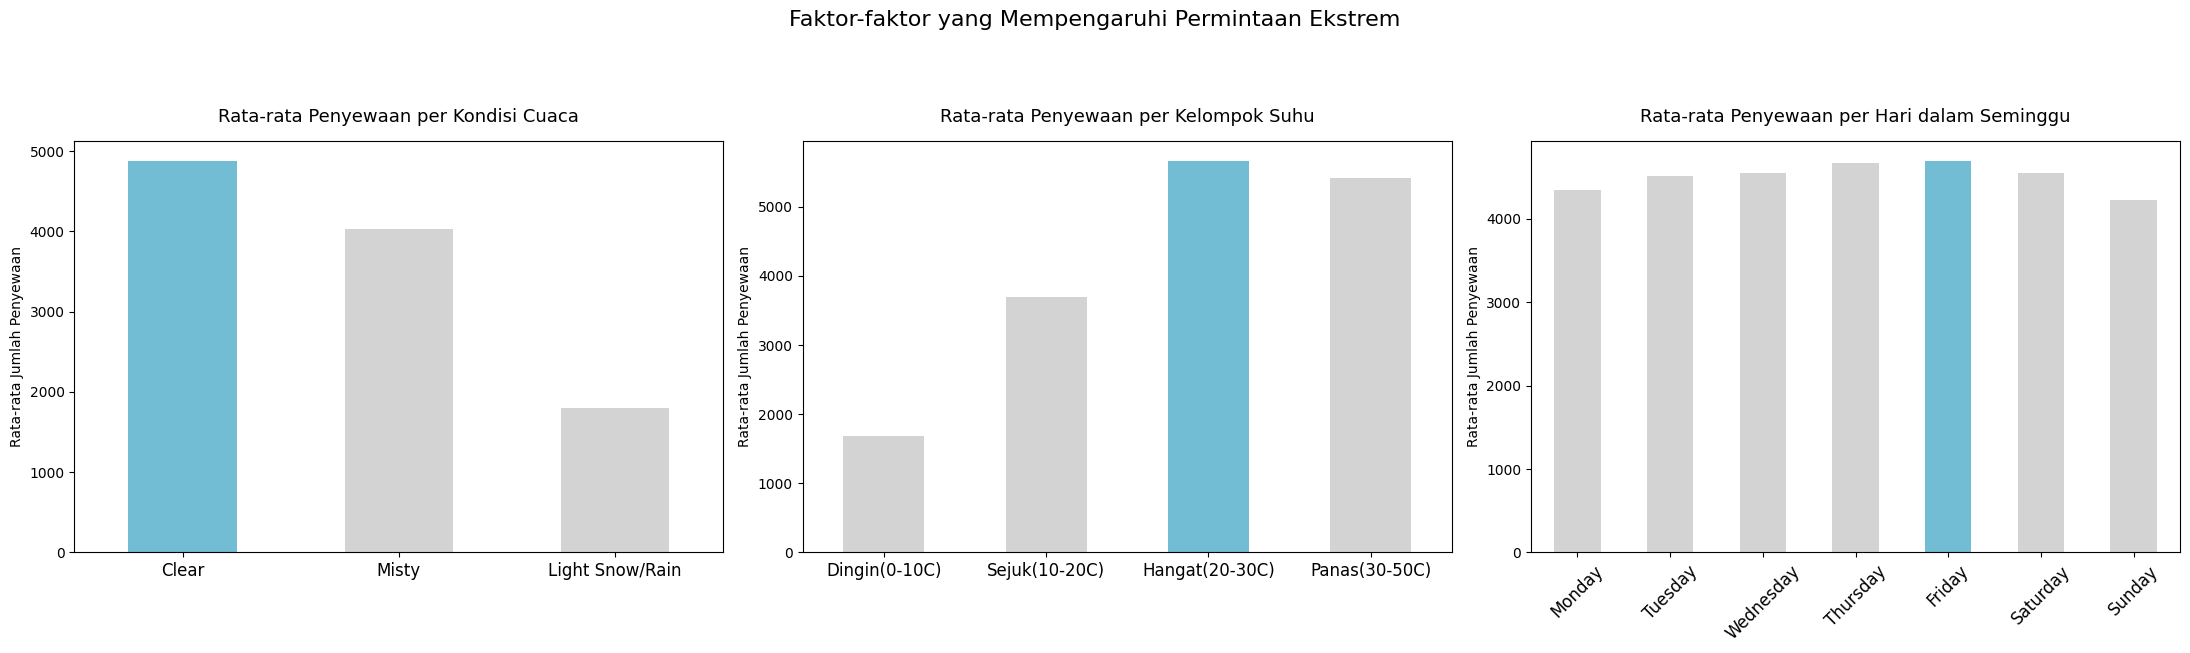

In [36]:
# 3 Faktor (Cuaca, Suhu, dan Jenis Hari)
data_to_plot = [
    day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False),
    day_df.groupby('kategori_suhu', observed=True)['cnt'].mean(),
    day_df.groupby('weekday')['cnt'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
]

titles = [
    'Rata-rata Penyewaan per Kondisi Cuaca',
    'Rata-rata Penyewaan per Kelompok Suhu',
    'Rata-rata Penyewaan per Hari dalam Seminggu'
]

# Visualisasi Bar Plot
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))

for i, data in enumerate(data_to_plot):
  colors = ['#72BCD4' if (val == data.max()) else '#D3D3D3' for val in data]

  rotation_val = 45 if i == 2 else 0

  data.plot(
        kind='bar',
        color=colors,
        ax=ax[i],
        rot=rotation_val
    )

  ax[i].set_title(titles[i], fontsize=13, pad=14)
  ax[i].set_xlabel(None)
  ax[i].set_ylabel('Rata-rata Jumlah Penyewaan')
  ax[i].tick_params(axis='x', labelsize=12)

plt.suptitle('Faktor-faktor yang Mempengaruhi Permintaan Ekstrem', fontsize=16, y=1.08)
plt.tight_layout()
plt.show()

### Visualisasi diatas menunjukkan faktor-faktor yang paling sering berkontribusi pada permintaan yang tinggi dan rendah pada bisnis *Bike Sharing*.

**Interpretasi Data:**
1. Faktor Cuaca: merupakan salah satu faktor yang mempengaruhi penyewaan sepeda setiap hari nya. Saat cuaca cerat (clear), rata-rata penyewaan mencapai tingkat tertinggi sekitar 4000 lebih permintaan, karena kondisi ini paling nyaman bagi semua pengguna. Pada kondisi cuaca lain, khususnya pada saat turunnya hujan atau salju, jumlah permintaan menurun kurang dari 2000 penyewaan, menunjukkan bahwa turunnya hujan atau salju ringan menjadi penghalang utama penggunaan sepeda.
2. Faktor Suhu: pemintaan tertinggi terjadi pada suhu yang hangat, sekitar 20-30 derajat celcius, karena suhu ini paling cocok untuk bersepeda. Sebaliknya, pada suhu dingin sekitar 0-10 derajat celcius jumlah penyewaan menurun karena udara terlalu dingin dan mengurangi minat pengguna. Selain itu, ketika suhu menjadi terlalu panas diatas 30 derajat celcius, jumlah penyewaan menurun dan menunjukkan bahwa suhu lingkungan yang panas mengurangi kenyamanan pengguna untuk bersepeda.
3. Faktor Jenis Hari: pada visual ketiga menunjukkan bahwa permintaan penyewaan sepeda cenderung stabil dan tinggi selama hari kerja, dengan puncaknya pada hari Jumat, yang menunjukkan peningkatan mobilitas menjelang akhir pekan. Sebaliknya, pada akhir pekan khususnya hari Minggu terjadi penurunan, meskipun permintaan tetap terhitung tinggi. Perbedaan volume permintaan pada tiap-tiap hari tidak terlalu besar yang menunjukkan bahwa layanan bike sharing cukup konsisten setiap harinya.

Berdasarkan interpretasi tersebut, bisa disimpulkan bahwa ketika cuaca cerah dan suhu berada diantara 20-30 derajat celcius, permintaan sepeda menjadi sangat tinggi, dengan rata-rata 5000. Sebaliknya, ketika cuaca buruk seperti turunnya hujan atau salju dan suhu berada dibawah 10 derajat celcius, membuat permintaan menurun secara signifikan hingga dibawah 2000. Selain itu, ketika suhu lingkungan panas ternyata tidak terlalu berdampak besar penurunannya dibandingkan dengan suhu dingin. Khususnya selama hari kerja, penyewaan akan tetap stabil dari sisi pengguna yang terdaftar. Hal ini menunjukkan bahwa penggunaan sepeda didominasi oleh kebutuhan mobilitas sehari-hari dan bahwa faktor cuaca merupakan risiko utama, sementara hari kerja memberikan stabilitas pendapatan bagi bisnis bike sharing.

### Pertanyaan 2: Pada hari kerja, akhir pekan, dan libur nasional, bagaimana perbedaan perilaku masing-masing pengguna (terdaftar dan kasual) dalam menyewa sepeda?


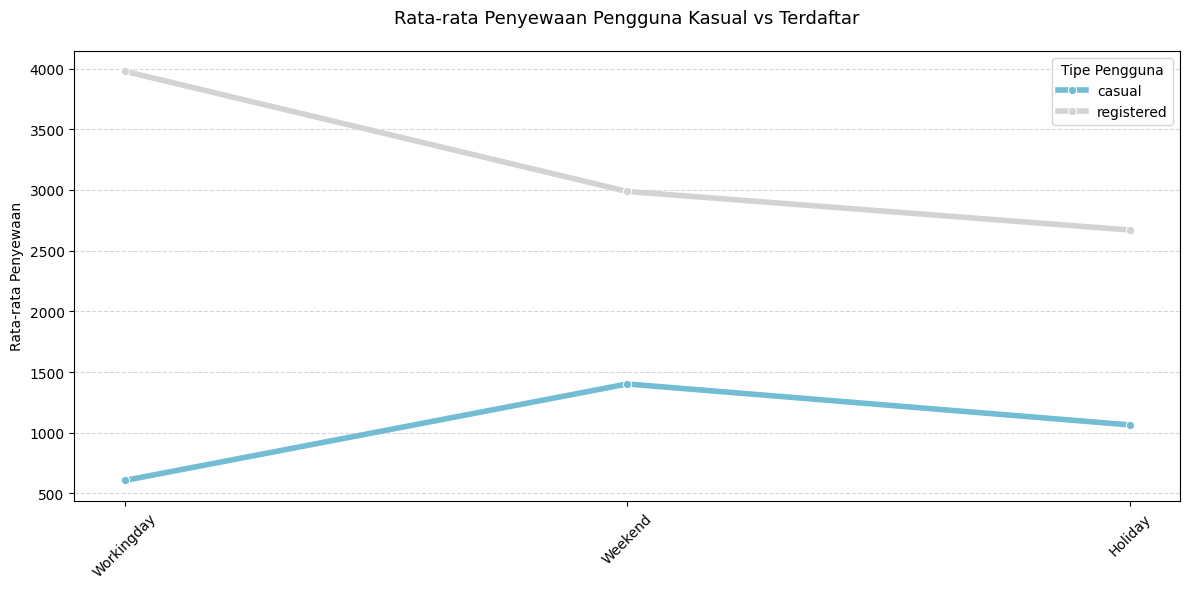

In [63]:
# Rata-rata penyewaan
day_type_avg = day_df.groupby('day_type')[['casual', 'registered']].mean().reindex(['Workingday', 'Weekend', 'Holiday']).reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(data=day_type_avg, x='day_type', y='casual', marker='o', label='casual', color='#72BCD4', linewidth=4)
sns.lineplot(data=day_type_avg, x='day_type', y='registered', marker='o', label='registered', color='#D3D3D3', linewidth=4)

plt.title('Rata-rata Penyewaan Pengguna Kasual vs Terdaftar', loc='center', fontsize=13, pad=20)
plt.xlabel(None)
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(rotation=45)
plt.legend(title='Tipe Pengguna')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Visualisasi line chart diatas digunakan untuk menunjukkan perbedaan pada pola penggunaan sepeda antara dua jenis pengguna (kasual dan terdaftar).

**Interpretasi Data:**
1. Workingday: dengan rata-rata sekitar 4000 permintaan, pengguna terdaftar lebih banyak mengendarai sepeda daripada pengguna kasual, yang hanya sekitar 600 permintaan. Maka dari itu, pengguna terdaftar sering menggunakan sepeda untuk bekerja atau sekolah, sementara pengguna kasual sangat sedikit menggunakan sepeda dihari kerja.
2. Weekend: akhir pekan menjadi waktu rekreasi bagi pengguna kasual, sedangkan pengguna terdaftar berkurang karena tidak ada kebutuhan komuter. Sehingga, pengguna kasual meningkat tajam menjadi sekitar 1400 sementara pengguna terdaftar turun sekitar 3000 permintaan.
3. Holday: dibandingkan dnegan akhir pekan, permintaan kedua pengguna menurun. Pengguna terdaftar menurun sekitar 2700 permintaan, sedangkan pengguna kasual turun sekitar 1000 permintaan. Dapat diketahui bahwa hari libur nasioal tidak serta merta meningkatkan permintaan penyewaan, sebaliknya permintaan malah turun.

Berdasarkan interpretasi data tersebut terdapat perbedaan yang jelas antara kedua tipe pengguna, telihat dari banyaknya aktivitas pad ahari kerja, pengguna terdaftar cenderung merupakan pengguna yang fokus memanfaatkan layanan untuk kebutuhan transportasi sehari-hari, sedangkan pengguna kasual lebih bersifat rekreasional dan meningkat saat akhir pekan, ketika mereka memiliki waktu luang. Namun, ketika lihat pada hari libur nasional, terjadi penurunan pada kedua tipe pengguna.


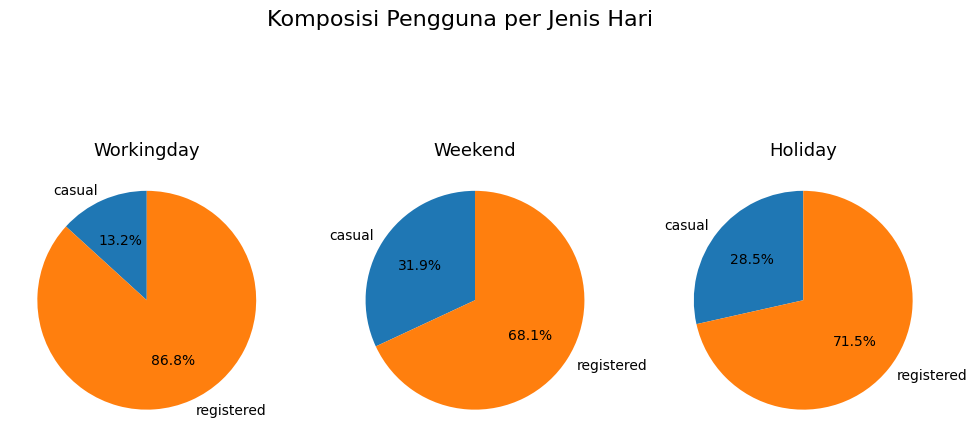

In [61]:
# Komposisi pengguna per jenis hari
pengguna = day_df.groupby('day_type')[['casual', 'registered']].mean().reindex(['Workingday', 'Weekend', 'Holiday'])

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))

for i, day in enumerate(['Workingday', 'Weekend', 'Holiday']):
  data = pengguna.loc[day]
  ax[i].pie(
      data,
      labels=data.index,
      autopct='%.1f%%',
      startangle=90
  )
  ax[i].set_title(f'{day}', loc='center', fontsize=13)

plt.suptitle('Komposisi Pengguna per Jenis Hari', fontsize=16)
plt.show()

### Visualisasi pie chart diatas untuk menunjukkan komposisi pengguna kasual dan terdaftar pada tiap jenis hari

**Interpretasi Data:**
1. Workingday: pengguna terdaftar sebesar 86,8%, sementara pengguna kasual 13,2%, menunjukkan bahwa pengguna rutin sepeda hampir sepenuhnya digunakan untuk komuter dihari kerja.
2. Weekend: permintaan pengguna kasual meningkat signifikan menjadi 31,9% sementara permintaan pengguna terdaftar menurun menjadi 68,1%. Peningkatan dua kali lipat dari hari kerja ini menunjukkan bahwa akhir pekan menarik lebih banyak pelanggan baru yang menyewa sepeda untuk rekreasi.
3. Holiday: presentase pengguna kasual menurun ke 28,5%, sedangkan pengguna terdaftar naik ke 71,5%. Sehingga, penurunan dan peningkatan permintaan tidak selalu berkaitan dengan hari libur nasional.

Ketiga pie chart konsisten menunjukkan bahwa pengguna terdaftar selalu mendominasi permintaan di semua jenis hari (workingday, weekend, dan holiday). Namun, selalu ada peningkatan yang baik bagi pengguna kasual setiap akhir pekan.

**Insight:**

Kedua visualisasi (line chart dan pie chart) menunjukkan perbedaan perilaku yang jelas antara pengguna terdaftar dan pengguna kasual setiap harinya.

- Pengguna terdaftar sellau mendominasi penyewaan di semua hari dengan proporsi minimal 68%, tetapi hari kerja memiliki aktivitas tertinggi dengan sekitar 4000 permintaan atau 86,8% dari total permintaan.
- Pengguna kasual disisi lain menunjukkan pola yang berlawanan, dumana aktivitas mereka meningkat seiring dengan penurunan jumlah permintaan pengguna terdaftar. Puncak penyewaan terjadi pada akhir pekan dengan rata-rata sekitar 1400, hampir dua kali lipat dari hari kerja, yang hanya 600 permintaan.
- Kedua pengguna tidak memiiki permintaan yang tinggi ketika hari libur nasional. Karena tidak ada permintaan komuter, jumlah pengguna terdaftar turun drastis, sementara jumlah pengguna kasual tidak meningkat seperti diakhir pekan, menjadikan hari libur nasional sebagai kondisi dengan permintaan total paling rendah.

Dengan begitu bisa disimpulkan bahwa pengguna terdaftar menyewa sepeda karena didorong oleh kebutuhan, sedangkan pengguna kasual didorong oleh waktu luang.

## Analisis Lanjutan (Opsional)

**Berdasarkan hasil analisis diatas, bisa disimpulkan bahwa memang pengguna layanan Bike Sharing ini didominasi oleh pengguna terdaftar. Maka dari itu, untuk analisis lanjutan akan menggunakan teknik simulasi skenario dengan menghitung proporsi kontribusi dari tiap jenis pengguna terhadap total penyewaan, guna untuk mengetahui sejauh mana bisnis bergantung pada pelanggan terdaftar, dan seberapa besar dampaknya ke total pendapatan jika pengguna terdaftar turun drastis.**


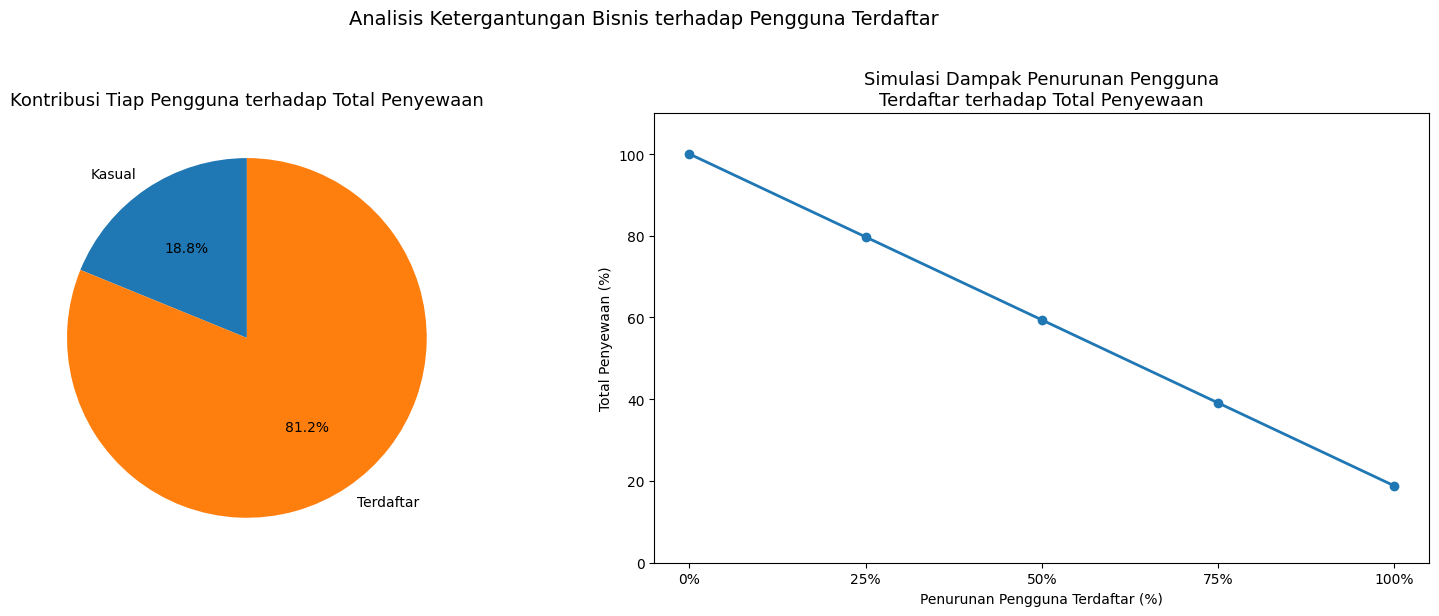

In [64]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Kontribusi Tiap Pengguna
total_casual = day_df['casual'].sum()
total_registered = day_df['registered'].sum()
total_cnt = day_df['cnt'].sum()

pct_casual = (total_casual / total_cnt) * 100
pct_registered = (total_registered / total_cnt) * 100

# Pie Chart -> Kontribusi Tiap Pengguna (%)
ax[0].pie(
    [pct_casual, pct_registered],
    labels=['Kasual', 'Terdaftar'],
    autopct=lambda p: f'{p:.1f}%',
    startangle=90
)

ax[0].set_title('Kontribusi Tiap Pengguna terhadap Total Penyewaan', fontsize=13)

# Line Chart -> Simulasi Penurunan Permintaan (Kontribusi Pengguna Terdaftar)
penurunan = [0, 25, 50, 75, 100]
simulasi = []
for p in penurunan:
    total_baru = pct_casual + (pct_registered * (1 - p/100))
    simulasi.append(total_baru)

ax[1].plot(penurunan, simulasi, marker='o', linewidth=2)
ax[1].set_title('Simulasi Dampak Penurunan Pengguna\nTerdaftar terhadap Total Penyewaan', fontsize=13)
ax[1].set_xlabel('Penurunan Pengguna Terdaftar (%)')
ax[1].set_ylabel('Total Penyewaan (%)')
ax[1].set_xticks(penurunan)
ax[1].set_xticklabels([f'{p}%' for p in penurunan])
ax[1].set_ylim(0, 110)

plt.suptitle('Analisis Ketergantungan Bisnis terhadap Pengguna Terdaftar', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi Data:**
1. Kontribusi Pengguna: pengguna terdaftar menyumbang sebanyak 81,2% dari total penyewaan, sementara pengguna kasual hanya menyumbang 18,8%. Ketidaksesuaian ini menunjukkan bahwa bisnis sangat amat bergantung pada satu tipe pelanggan.
2. Dampak Penurunan: berdasarkan line chart bisa dilihat bahwa adanya penurunan yang signifikan seiring berkurangnya pengguna terdaftar. Penurunan sebesar 25% pengguna terdaftar pada total penyewaan tersisa sekitar 80%, penurunan sebesar 50% pada total penyewaan tersisa sekitar 60%, dan penurunan sebesar 100% pada total penyewaan tersisa kurang dari 20%, yang dimana, itu adalah total dari pengguna kasual.

Maka dari itu, karena sangat amat bergantung pada pengguna terdaftar, bisnis Bike Sharing berada pada kondisi yang rentan, sehingga diperlukan adanya diversifikasi dengan meningkatkan tipe pengguna yang tidak terdaftar menjadi kunci utama untuk meningkatkan revenue dan keberlangsungan bisnis, jika suatu saat permintaan dari pengguna terdaftar perlahan menurun, khususnya pada hari kerja (weekday) yang pastinya akan sangat berdampak pada total penyewaan.

## Conclusion

Berikut ini merupakan ringkasan hasil analisis dan rekomendasi strategis yang dapat diterapkan dari semua hasil analisis, mulai dari Data Wrangling, Analisis Data Exploratory (EDA), Visualization & Explanatory, hingga tahap Conclusion ini.

- Conclution pertanyaan 1:
Faktor utama yang mempengaruhi permintana untuk penyewaan sepeda adalah cuaca cerah yang mendorong rata-rata 5000 penyewaan per hari. Sementara, permintaan terjadi penurunan ketika cuaca sedang hujan atau salju ringan hingga 2000 permintaan. Faktor cuaca merupakan risiko utama penurunan permintaan pada bisnis Bike Sharing. Selain itu, suhu ideal untuk bersepeda sekitar 20-30 derajat celcius, kalau suhu terlalu dingin kurang dari 10 derajat celcius, permintaan akan turun, begitupula ketika cuaca terlalu panas lebih dari 30 derajat celcius, dimana suhu lingkungan tersebut kurang diminati oleh pengguna untuk melakukan penyewaan sepeda. Hari jumat juga sebagai penyumbang permintaan tertinggi, sedangkan hari minggu menjadi hari dimana penyewaan terendah. Kondisi yang paling menguntungkan bagi bisnis adalah kombinasi cuaca cerah dan suhu hangat pada hari Jumat, sedangkan kondisi yang paling berisiko adalah kombinasi hujan dan salju dan suhu dingin pada hari Minggu.


- Conclution pertanyaan 2:
Pengguna terdaftar memiliki kontribusi yang sangat dominan sebesar 81% dari total penyewaan, dengan 86,8& aktivitas terjadi pada hari kerja. Pengguna terdaftar menggunakan sepeda sebagai alat transportasi sehari-hari. Kalau pengguna kasual lebih santai dalam menyewa sepeda, karena permintaan pengguna kasual meningkat hanya diakhir pekan. Namun, kontribusinya terhadap total penyewaan hanya sebesar 19 persen, membuat bisnis sangat rentan jika ada penurunan pengguna. Lalu pada hari nasioanl, menghasilkan permintaan terendah karena penurunan permintaan yang signifikan pada pengguna terdaftar dan tidak adanya peningkatan yang signifikan oleh pengguna kasual.


In [66]:
day_df.to_csv('day_data.csv', index=False)